Found 7750 images belonging to 2 classes.
Found 744 images belonging to 2 classes.
Found 364 images belonging to 2 classes.


C:\Users\Bsi\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 634s 3s/step - accuracy: 0.7963 - loss: 0.4238 - val_accuracy: 0.8589 - val_loss: 0.2790
Epoch 2/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 544s 2s/step - accuracy: 0.9159 - loss: 0.2213 - val_accuracy: 0.8831 - val_loss: 0.2783
Epoch 3/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 532s 2s/step - accuracy: 0.9338 - loss: 0.1717 - val_accuracy: 0.9180 - val_loss: 0.2186
Epoch 4/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 539s 2s/step - accuracy: 0.9403 - loss: 0.1572 - val_accuracy: 0.9247 - val_loss: 0.1843
Epoch 5/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 536s 2s/step - accuracy: 0.9415 - loss: 0.1576 - val_accuracy: 0.8992 - val_loss: 0.2135
Epoch 6/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 524s 2s/step - accuracy: 0.9478 - loss: 0.1381 - val_accuracy: 0.9194 - val_loss: 0.1755
Epoch 7/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 518s 2s/step - accuracy: 0.9536 - loss: 0.1254 - val_accuracy: 0.9194 - val_loss: 0.1595
Epoch 8/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 525s 2s/step - accuracy: 0.9564 - loss: 0.1288 - val_accu

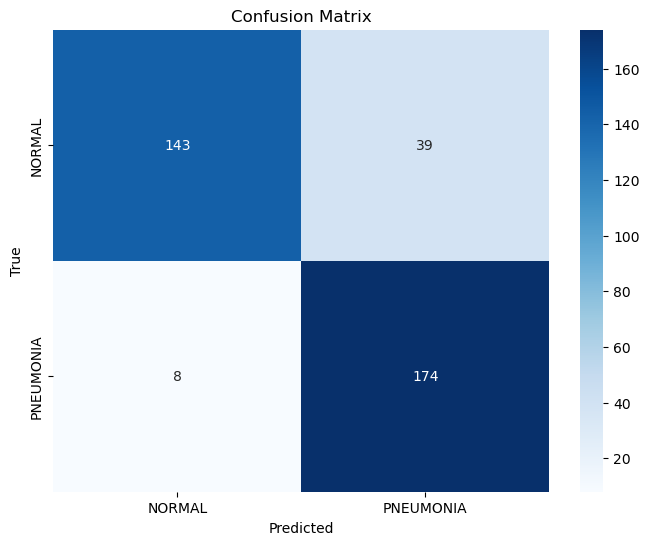

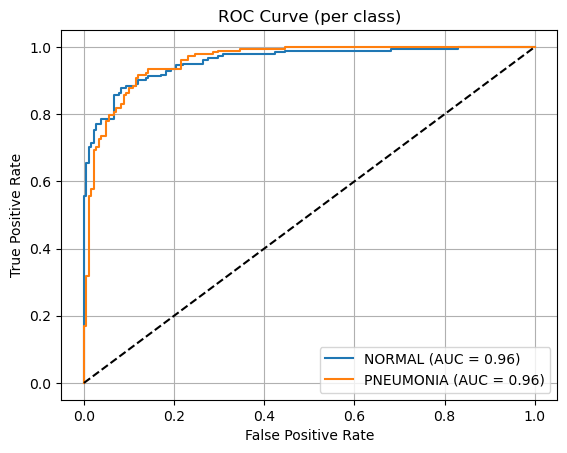

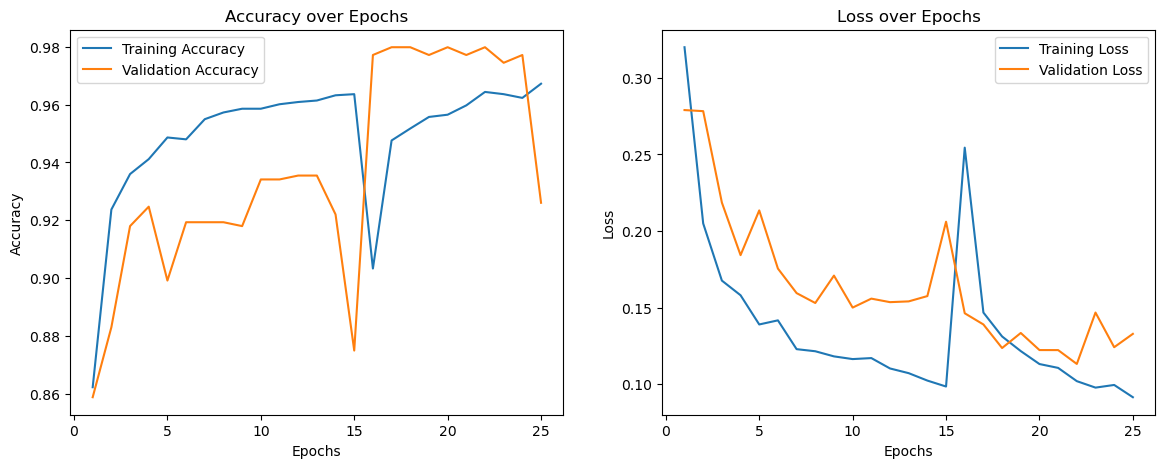

In [1]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
#preparation de donnees
train_dir = 'D:/Data-Chest-ray/train'
val_dir = 'D:/Data-Chest-ray/val'
test_dir = 'D:/Data-Chest-ray/test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=15,
                                   zoom_range=0.1,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE,
                                              batch_size=BATCH_SIZE, class_mode='categorical')
val_gen = val_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE,
                                          batch_size=BATCH_SIZE, class_mode='categorical')
test_gen = val_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE,
                                           batch_size=1, class_mode='categorical', shuffle=False)
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(train_gen.num_classes, activation='softmax')
])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
history_1 = model.fit(train_gen, validation_data=val_gen, epochs=15, callbacks=[early_stop])
# Fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history_2 = model.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=[early_stop])
# Prédictions
pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes
target_names = list(test_gen.class_indices.keys())

# Rapport de classification
print(classification_report(y_true, y_pred, target_names=target_names))

# F1-score
f1 = f1_score(y_true, y_pred, average='macro')
print("F1-score (macro):", f1)

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Courbes ROC pour chaque classe
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(len(target_names)):
    fpr[i], tpr[i], _ = roc_curve(test_gen.labels == i, pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (per class)')
plt.legend()
plt.grid(True)
plt.show()
def plot_learning_curves(history_list, labels):
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs_range = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Appeler la fonction
plot_learning_curves([history_1, history_2], ['Phase 1', 'Phase 2'])
import matplotlib.pyplot as plt

fig_dir = 'C:/Users/Bsi/OneDrive/Bureau/Dania/Data-Chest-ray/Data-Chest-ray'
os.makedirs(fig_dir, exist_ok=True)

# Courbe d'apprentissage
def save_learning_curves(history_list, save_path):
    acc, val_acc, loss, val_loss = [], [], [], []
    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.legend()

    plt.savefig(os.path.join(save_path, 'learning_curves.png'))
    plt.close()

save_learning_curves([history_1, history_2], fig_dir)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'confusion_matrix.png'))
plt.close()
plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'roc_curve.png'))
plt.close()



In [3]:
import matplotlib.pyplot as plt

fig_dir = 'D:/Data-Chest-ray'
os.makedirs(fig_dir, exist_ok=True)

# Courbe d'apprentissage
def save_learning_curves(history_list, save_path):
    acc, val_acc, loss, val_loss = [], [], [], []
    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.legend()

    plt.savefig(os.path.join(save_path, 'learning_curves.png'))
    plt.close()

save_learning_curves([history_1, history_2], fig_dir)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'confusion_matrix.png'))
plt.close()
plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'roc_curve.png'))
plt.close()



In [7]:
# save
model_save_path = 'D:/Data-Chest-ray'
os.makedirs(model_save_path, exist_ok=True)

# Sauvegarder le modèle final
model.save(os.path.join(model_save_path, 'DenseNet121perfect_finetuned_model.keras'))
print("✅ Modèle enregistré avec succès dans pc.")

✅ Modèle enregistré avec succès dans pc.


Found 7750 images belonging to 2 classes.
Found 744 images belonging to 2 classes.
Found 364 images belonging to 2 classes.


C:\Users\Bsi\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 522s 2s/step - accuracy: 0.5898 - loss: 1.0556 - val_accuracy: 0.8495 - val_loss: 0.3874
Epoch 2/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 415s 2s/step - accuracy: 0.7964 - loss: 0.4404 - val_accuracy: 0.9086 - val_loss: 0.2936
Epoch 3/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 444s 2s/step - accuracy: 0.8606 - loss: 0.3420 - val_accuracy: 0.9046 - val_loss: 0.2651
Epoch 4/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 423s 2s/step - accuracy: 0.8890 - loss: 0.2849 - val_accuracy: 0.9073 - val_loss: 0.2484
Epoch 5/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 440s 2s/step - accuracy: 0.8965 - loss: 0.2758 - val_accuracy: 0.9059 - val_loss: 0.2634
Epoch 6/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 427s 2s/step - accuracy: 0.9072 - loss: 0.2363 - val_accuracy: 0.9099 - val_loss: 0.2390
Epoch 7/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 433s 2s/step - accuracy: 0.9154 - loss: 0.2381 - val_accuracy: 0.8871 - val_loss: 0.2308
Epoch 8/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 441s 2s/step - accuracy: 0.9117 - loss: 0.2400 - val_accu

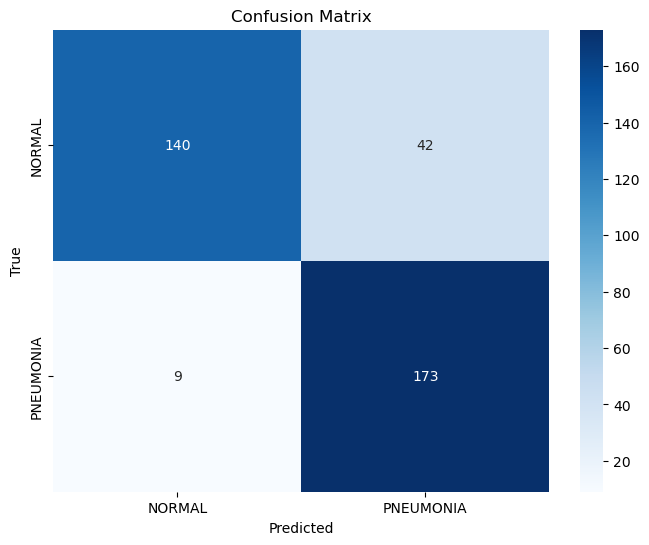

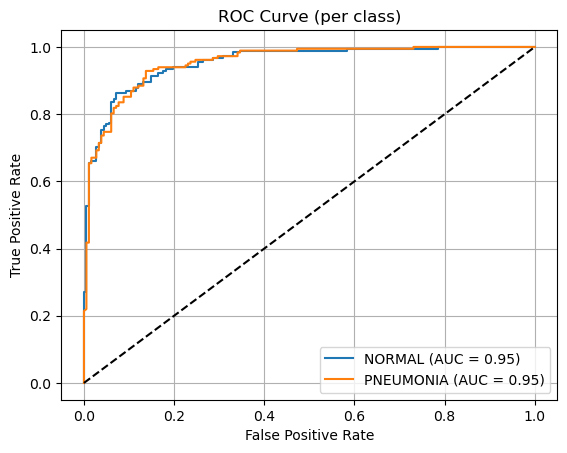

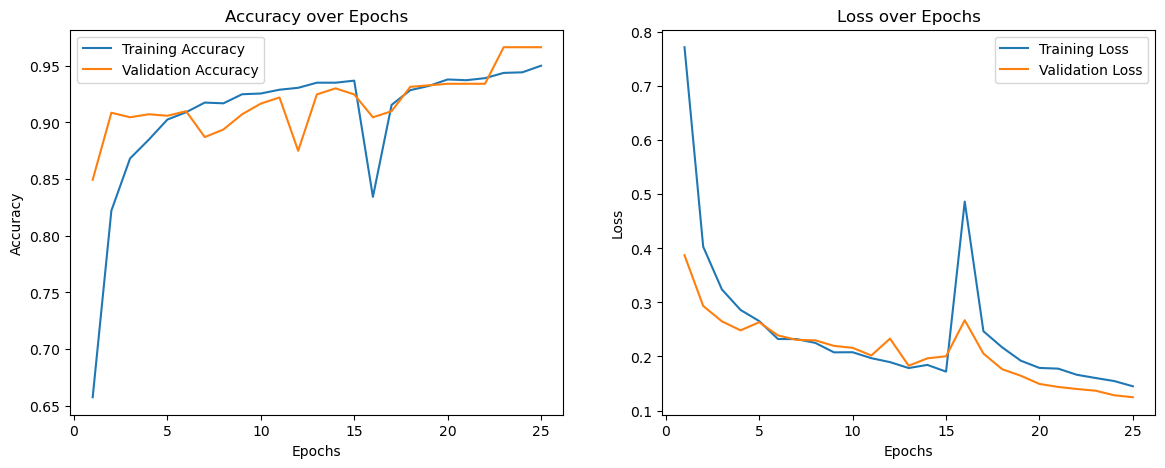

In [1]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
#preparation de donnees
train_dir = 'D:/Data-Chest-ray/train'
val_dir = 'D:/Data-Chest-ray/val'
test_dir = 'D:/Data-Chest-ray/test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=15,
                                   zoom_range=0.1,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE,
                                              batch_size=BATCH_SIZE, class_mode='categorical')
val_gen = val_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE,
                                          batch_size=BATCH_SIZE, class_mode='categorical')
test_gen = val_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE,
                                           batch_size=1, class_mode='categorical', shuffle=False)
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.7),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.7),
    layers.Dense(train_gen.num_classes, activation='softmax')
])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
history_1 = model.fit(train_gen, validation_data=val_gen, epochs=15, callbacks=[early_stop])
# Fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history_2 = model.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=[early_stop])
# Prédictions
pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes
target_names = list(test_gen.class_indices.keys())

# Rapport de classification
print(classification_report(y_true, y_pred, target_names=target_names))

# F1-score
f1 = f1_score(y_true, y_pred, average='macro')
print("F1-score (macro):", f1)

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Courbes ROC pour chaque classe
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(len(target_names)):
    fpr[i], tpr[i], _ = roc_curve(test_gen.labels == i, pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (per class)')
plt.legend()
plt.grid(True)
plt.show()
def plot_learning_curves(history_list, labels):
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs_range = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Appeler la fonction
plot_learning_curves([history_1, history_2], ['Phase 1', 'Phase 2'])
import matplotlib.pyplot as plt

fig_dir = 'C:/Users/Bsi/OneDrive/Bureau/Dania/Data-Chest-ray/Data-Chest-ray'
os.makedirs(fig_dir, exist_ok=True)

# Courbe d'apprentissage
def save_learning_curves(history_list, save_path):
    acc, val_acc, loss, val_loss = [], [], [], []
    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.legend()

    plt.savefig(os.path.join(save_path, 'learning_curves.png'))
    plt.close()

save_learning_curves([history_1, history_2], fig_dir)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'confusion_matrix.png'))
plt.close()
plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'roc_curve.png'))
plt.close()

